LOGISTIC REGRESSION ANALYSIS AND GRADIENT-BOOSTING

In [5]:
# Import all necessary libraries
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report

# LOAD the dataset
file_path = "2023_naturaldisasters2.xlsx"
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('2023_naturaldisasters')

# Define six significant predictor variables based on chi-square analysis
selected_vars = [
    'socioeconomically_disadvantaged', 'homeownership', 'education',
    'race_selfid', 'englishlang', 'sixtyplus'
]

# Drop rows with missing values
filtered_df = df[selected_vars + ['Prep_2lvls']].dropna()

# Encode categorical variables
label_encoders = {}
for col in selected_vars + ['Prep_2lvls']:
    le = LabelEncoder()
    filtered_df[col] = le.fit_transform(filtered_df[col])
    label_encoders[col] = le

# Define features and target variable
X = filtered_df[selected_vars]
y = filtered_df['Prep_2lvls']

# Split the dataset into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Initialize and train logistic regression model
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Predict and evaluate model
y_pred = log_model.predict(X_test)
log_report = classification_report(y_test, y_pred, output_dict=True)

log_report


{'0': {'precision': 0.5733496332518337,
  'recall': 0.6106770833333334,
  'f1-score': 0.5914249684741488,
  'support': 768.0},
 '1': {'precision': 0.5746799431009957,
  'recall': 0.5365205843293492,
  'f1-score': 0.554945054945055,
  'support': 753.0},
 'accuracy': 0.5739644970414202,
 'macro avg': {'precision': 0.5740147881764147,
  'recall': 0.5735988338313414,
  'f1-score': 0.5731850117096019,
  'support': 1521.0},
 'weighted avg': {'precision': 0.5740082284631546,
  'recall': 0.5739644970414202,
  'f1-score': 0.5733648929400215,
  'support': 1521.0}}

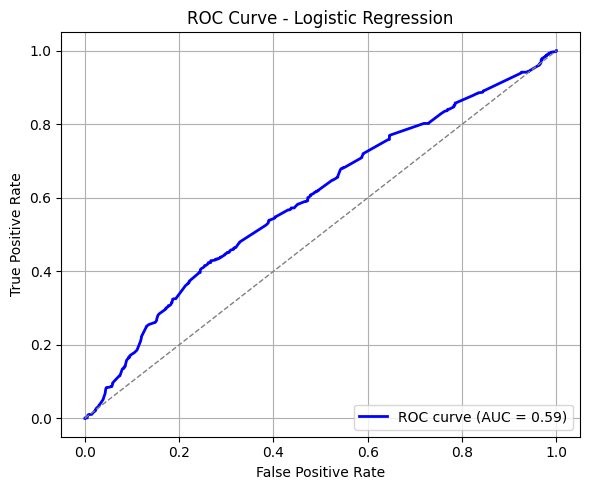

In [9]:
# Re-import matplotlib to resolve NameError
import matplotlib.pyplot as plt

# Recreate and save the ROC curve plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='blue', lw=2, label=f"ROC curve (AUC = {roc_auc:.2f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Logistic Regression")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


GRADIENT BOOSTING

In [10]:
# Train Gradient Boosting model with the same six selected features
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_curve, auc

# Prepare the data
X_gb = filtered_df[selected_vars]
y_gb = filtered_df['Prep_2lvls']
X_train_gb, X_test_gb, y_train_gb, y_test_gb = train_test_split(X_gb, y_gb, test_size=0.2, random_state=42)

# Train the model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train_gb, y_train_gb)

# Evaluate model
y_pred_gb = gb_model.predict(X_test_gb)
gb_report = classification_report(y_test_gb, y_pred_gb, output_dict=True)

# Predict probabilities for ROC
y_probs_gb = gb_model.predict_proba(X_test_gb)[:, 1]
fpr_gb, tpr_gb, _ = roc_curve(y_test_gb, y_probs_gb)
roc_auc_gb = auc(fpr_gb, tpr_gb)

gb_report, roc_auc_gb


({'0': {'precision': 0.5961844197138315,
   'recall': 0.48828125,
   'f1-score': 0.5368647100930566,
   'support': 768.0},
  '1': {'precision': 0.5594170403587444,
   'recall': 0.6626826029216467,
   'f1-score': 0.6066869300911855,
   'support': 753.0},
  'accuracy': 0.5746219592373438,
  'macro avg': {'precision': 0.577800730036288,
   'recall': 0.5754819264608233,
   'f1-score': 0.571775820092121,
   'support': 1521.0},
  'weighted avg': {'precision': 0.5779820287510566,
   'recall': 0.5746219592373438,
   'f1-score': 0.5714315290664892,
   'support': 1521.0}},
 np.float64(0.6164525924081451))

C:\Users\chris\AppData\Local\Temp\ipykernel_13464\1283253278.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=feature_importance, y=feature_importance.index, palette="viridis")


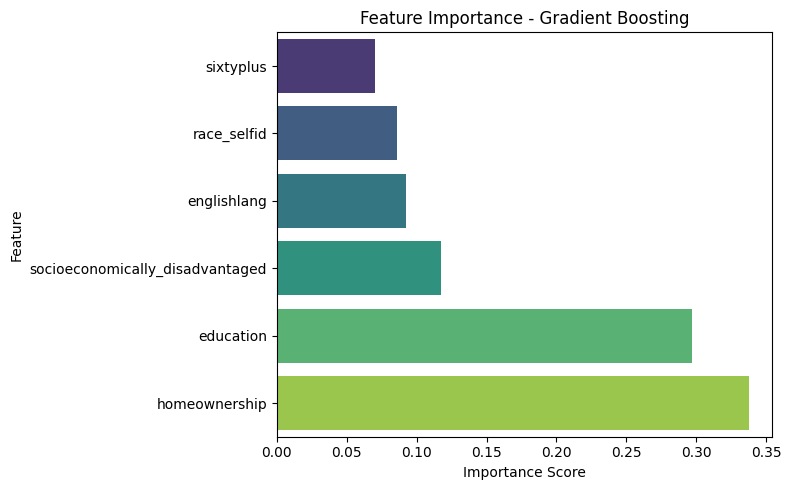

In [11]:
# Create and visualize feature importances from the trained Gradient Boosting model
import matplotlib.pyplot as plt
import seaborn as sns

# Get feature importances
feature_importance = pd.Series(gb_model.feature_importances_, index=X_gb.columns)
feature_importance = feature_importance.sort_values(ascending=True)

# Plot the feature importances
plt.figure(figsize=(8, 5))
sns.barplot(x=feature_importance, y=feature_importance.index, palette="viridis")
plt.title("Feature Importance - Gradient Boosting")
plt.xlabel("Importance Score")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


MACHINE LEARNING AND MODEL DEPLOYMENT

In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score



# Reload the dataset after re-upload
file_path = "2023_naturaldisasters2.xlsx"
excel_data = pd.ExcelFile(file_path)
df = excel_data.parse('2023_naturaldisasters')

# Define selected features
selected_vars = [
    'socioeconomically_disadvantaged', 'homeownership', 'education',
    'race_selfid', 'englishlang', 'sixtyplus'
]

# Drop missing and encode
df_clean = df[selected_vars + ['Prep_2lvls']].dropna()
for col in df_clean.columns:
    le = LabelEncoder()
    df_clean[col] = le.fit_transform(df_clean[col])

# Define features and target
X = df_clean[selected_vars]
y = df_clean['Prep_2lvls']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train Gradient Boosting model
gb_model = GradientBoostingClassifier(random_state=42)
gb_model.fit(X_train, y_train)

# Evaluate model
y_pred = gb_model.predict(X_test)
y_probs = gb_model.predict_proba(X_test)[:, 1]
auc_score = roc_auc_score(y_test, y_probs)
report = classification_report(y_test, y_pred, output_dict=True)
feature_importance = pd.Series(gb_model.feature_importances_, index=X.columns).sort_values(ascending=False)

report, auc_score, feature_importance


({'0': {'precision': 0.5961844197138315,
   'recall': 0.48828125,
   'f1-score': 0.5368647100930566,
   'support': 768.0},
  '1': {'precision': 0.5594170403587444,
   'recall': 0.6626826029216467,
   'f1-score': 0.6066869300911855,
   'support': 753.0},
  'accuracy': 0.5746219592373438,
  'macro avg': {'precision': 0.577800730036288,
   'recall': 0.5754819264608233,
   'f1-score': 0.571775820092121,
   'support': 1521.0},
  'weighted avg': {'precision': 0.5779820287510566,
   'recall': 0.5746219592373438,
   'f1-score': 0.5714315290664892,
   'support': 1521.0}},
 np.float64(0.6164525924081451),
 homeownership                      0.337391
 education                          0.296728
 socioeconomically_disadvantaged    0.117236
 englishlang                        0.092625
 race_selfid                        0.085744
 sixtyplus                          0.070276
 dtype: float64)

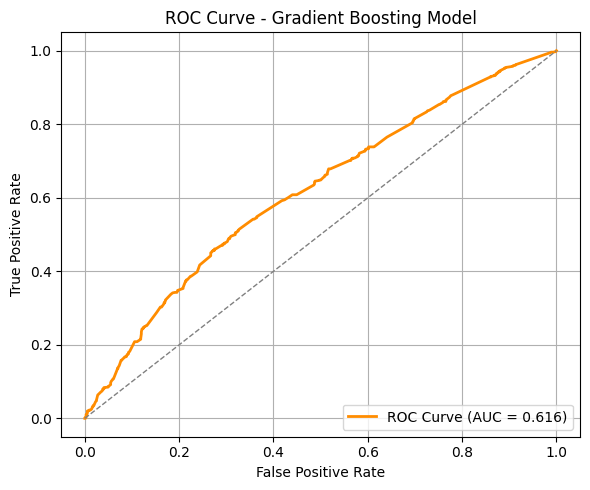

In [4]:
# Plot ROC curve for Gradient Boosting model to visualize AUC score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Compute ROC curve
fpr, tpr, _ = roc_curve(y_test, y_probs)
roc_auc = auc(fpr, tpr)

# Plot
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"ROC Curve (AUC = {roc_auc:.3f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Gradient Boosting Model")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()


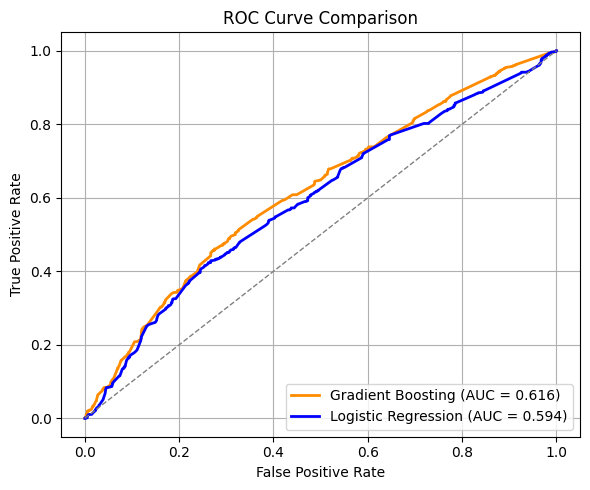

In [5]:
# Plot ROC curve for Gradient Boosting model to visualize AUC score
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Import the missing class
from sklearn.linear_model import LogisticRegression

# Recreate the logistic regression model and fit it
log_model = LogisticRegression(max_iter=1000, random_state=42)
log_model.fit(X_train, y_train)

# Get predicted probabilities
y_probs_log = log_model.predict_proba(X_test)[:, 1]

# Compute ROC curve for logistic regression
fpr_log, tpr_log, _ = roc_curve(y_test, y_probs_log)
auc_log = auc(fpr_log, tpr_log)

# Plot ROC curves for both models
plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f"Gradient Boosting (AUC = {roc_auc:.3f})")
plt.plot(fpr_log, tpr_log, color='blue', lw=2, label=f"Logistic Regression (AUC = {auc_log:.3f})")
plt.plot([0, 1], [0, 1], color='gray', lw=1, linestyle='--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")
plt.grid(True)
plt.tight_layout()
plt.show()

MODEL DEPLOYMENT

In [6]:
from joblib import dump
dump(gb_model, 'preparedness_model.joblib')


['preparedness_model.joblib']

In [7]:
import streamlit as st
import pandas as pd
from joblib import load

# Load model
model = load("preparedness_model.joblib")

st.title("Disaster Preparedness Predictor")

# Collect user input
age = st.selectbox("Are you 60 or older?", ["No", "Yes"])
socio = st.selectbox("Socioeconomically Disadvantaged?", ["No", "Yes"])
home = st.selectbox("Homeownership?", ["Renter", "Homeowner"])
edu = st.selectbox("Education Level", ["<HS", "HS", "Some College", "BA", "Grad"])
race = st.selectbox("Race", ["White", "Black", "Latino", "Asian", "Other"])
lang = st.selectbox("Primary Language", ["English", "Other"])

# Convert input to model-ready format
input_df = pd.DataFrame([{
    'socioeconomically_disadvantaged': 1 if socio == "Yes" else 0,
    'homeownership': 1 if home == "Homeowner" else 0,
    'education': ["<HS", "HS", "Some College", "BA", "Grad"].index(edu),
    'race_selfid': ["White", "Black", "Latino", "Asian", "Other"].index(race),
    'englishlang': 0 if lang == "Other" else 1,
    'sixtyplus': 1 if age == "Yes" else 0
}])

# Prediction
if st.button("Predict"):
    pred = model.predict(input_df)[0]
    st.success("Prepared" if pred == 1 else "Unprepared")


2025-04-27 21:56:36.524 
  command:

    streamlit run C:\Users\chris\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-04-27 21:56:36.524 Session state does not function when running a script without `streamlit run`
